# Objective:

1. This notebook builds predictive models using Gold layer KPIs
2. (employment, wages, participation rates) to forecast future workforce trends.

# Goals:

1. Load Gold layer KPI tables and insights.
2. Perform time-series forecasting for employment, wages, and participation rates.
3. Compare classical statistical models (ARIMA, ETS) with machine learning models (Random Forest, XGBoost).
4. Generate forecast visualizations and export results for dashboards.

# Enterprise Context:
1. Forecast outputs will feed into workforce planning dashboards,
2. enabling recruiters and managers to anticipate labor market shifts.


# Step 1: Upload KPI CSVs

In [1]:
from google.colab import files
import pandas as pd

# Upload KPI CSV files from your local machine
uploaded = files.upload()


Saving employment_kpi.csv to employment_kpi.csv
Saving oews_kpi.csv to oews_kpi.csv
Saving oews_wage_kpi.csv to oews_wage_kpi.csv
Saving participation_kpi.csv to participation_kpi.csv
Saving unemployment_kpi.csv to unemployment_kpi.csv
Saving wages_kpi.csv to wages_kpi.csv


In [14]:
from google.colab import files
import pandas as pd

# Upload the Silver Employment dataset again
uploaded = files.upload()   # select employment_clean.csv

# Load into Pandas
employment = pd.read_csv("employment_clean.csv")

print("✔ Silver Employment dataset loaded")
print(employment.head())


Saving employment_clean.csv to employment_clean.csv
✔ Silver Employment dataset loaded
  Area Type       Area Name  Year Time Period           Ownership  \
0    County  Alameda County  2020     1st Qtr  Federal Government   
1    County  Alameda County  2020     1st Qtr  Federal Government   
2    County  Alameda County  2020     1st Qtr  Federal Government   
3    County  Alameda County  2020     1st Qtr  Federal Government   
4    County  Alameda County  2020     1st Qtr  Federal Government   

   NAICS Level NAICS Code                        Industry Name  \
0            2       1024   Professional and Business Services   
1            3        491                       Postal Service   
2            3        541  Professional and Technical Services   
3            5      54133                 Engineering Services   
4            2         62    Health Care and Social Assistance   

   Establishments  Average Monthly Employment  1st Month Emp  2nd Month Emp  \
0               2     

# Step 1.1: Load into Pandas

In [2]:
# Load each KPI file into a DataFrame
oews_kpi = pd.read_csv("oews_kpi.csv")
oews_wage_kpi = pd.read_csv("oews_wage_kpi.csv")
employment_kpi = pd.read_csv("employment_kpi.csv")
wages_kpi = pd.read_csv("wages_kpi.csv")
participation_kpi = pd.read_csv("participation_kpi.csv")
unemployment_kpi = pd.read_csv("unemployment_kpi.csv")

print("✔ Gold KPI datasets loaded successfully")


✔ Gold KPI datasets loaded successfully


# Step 1.2: Quick Verification

In [3]:
# Check shapes and preview
print("OEWS KPI Shape:", oews_kpi.shape)
print("Employment KPI Shape:", employment_kpi.shape)
print("Participation KPI Shape:", participation_kpi.shape)

print("\nOEWS KPI Sample:\n", oews_kpi.head(3))
print("\nEmployment KPI Sample:\n", employment_kpi.head(3))
print("\nParticipation KPI Sample:\n", participation_kpi.head(3))


OEWS KPI Shape: (1040, 2)
Employment KPI Shape: (2411, 2)
Participation KPI Shape: (193, 2)

OEWS KPI Sample:
    Standard Occupational Classification  Number of Employed
0                                     0        1.076969e+09
1                                430000        1.558877e+08
2                                410000        1.023811e+08

Employment KPI Sample:
   NAICS Code  Average Monthly Employment
0      33611                93633.971429
1     336110                92815.692308
2         10                67339.587150

Participation KPI Sample:
       area_name  labor_force_participation_rate
0          IOWA                       70.075987
1  ADAIR COUNTY                             NaN
2  ADAMS COUNTY                             NaN


# Step 2: Employment KPI Forecasting

### 2.1 Prepare Employment Series

In [15]:
import pandas as pd

# Load the Silver Employment dataset (not the KPI snapshot)
employment = pd.read_csv("employment_clean.csv")

# Inspect columns
print(employment.columns)
print(employment.head())


Index(['Area Type', 'Area Name', 'Year', 'Time Period', 'Ownership',
       'NAICS Level', 'NAICS Code', 'Industry Name', 'Establishments',
       'Average Monthly Employment', '1st Month Emp', '2nd Month Emp',
       '3rd Month Emp', 'Total Wages (All Workers)', 'Average Weekly Wages'],
      dtype='object')
  Area Type       Area Name  Year Time Period           Ownership  \
0    County  Alameda County  2020     1st Qtr  Federal Government   
1    County  Alameda County  2020     1st Qtr  Federal Government   
2    County  Alameda County  2020     1st Qtr  Federal Government   
3    County  Alameda County  2020     1st Qtr  Federal Government   
4    County  Alameda County  2020     1st Qtr  Federal Government   

   NAICS Level NAICS Code                        Industry Name  \
0            2       1024   Professional and Business Services   
1            3        491                       Postal Service   
2            3        541  Professional and Technical Services   
3         

### Step 2.2 Build Employment Series

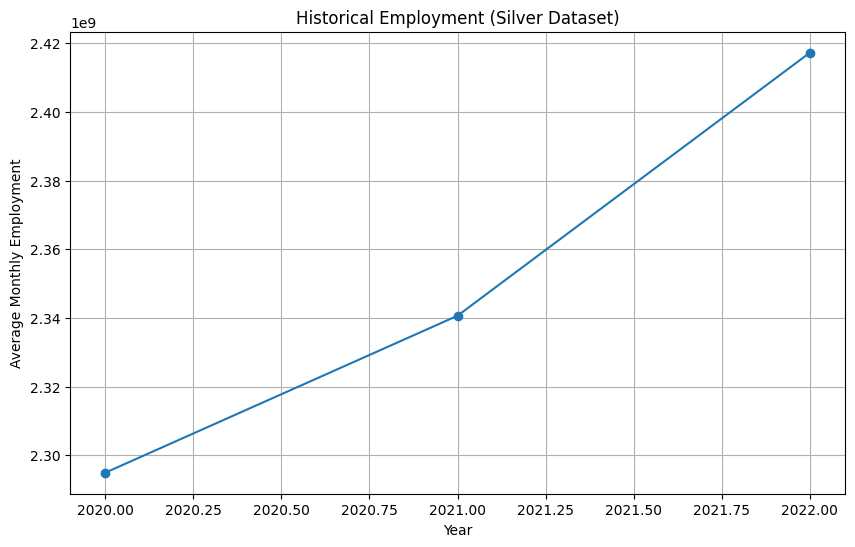

In [16]:
# Aggregate employment by Year
employment_series = employment.groupby("Year")["Average Monthly Employment"].sum()

# Quick visualization
import matplotlib.pyplot as plt
employment_series.plot(marker='o', figsize=(10,6))
plt.title("Historical Employment (Silver Dataset)")
plt.xlabel("Year")
plt.ylabel("Average Monthly Employment")
plt.grid(True)
plt.show()


### Step 2.3 Forecast with ARIMA

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for ARMA

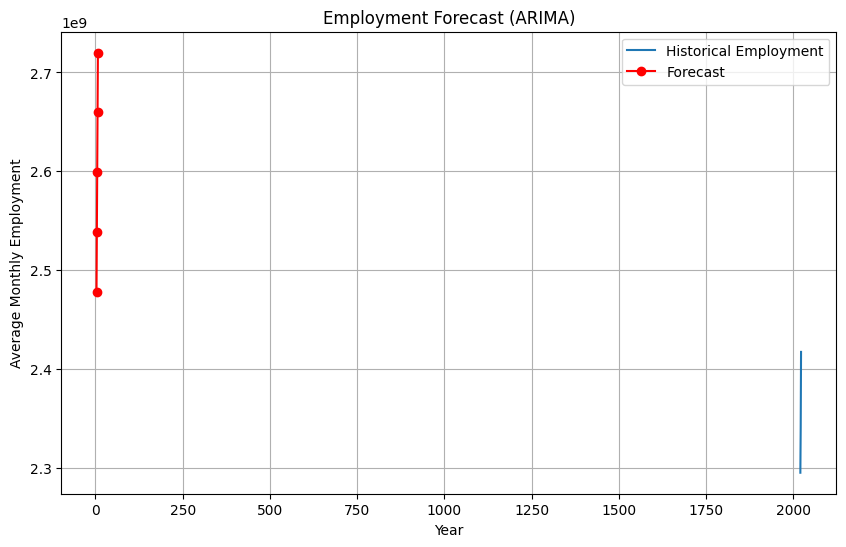

In [17]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model
model = ARIMA(employment_series, order=(1,1,1))
model_fit = model.fit()

# Forecast next 5 years
forecast = model_fit.forecast(steps=5)

# Plot forecast
plt.figure(figsize=(10,6))
plt.plot(employment_series, label="Historical Employment")
plt.plot(range(len(employment_series), len(employment_series)+5), forecast,
         label="Forecast", marker='o', color="red")
plt.title("Employment Forecast (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Average Monthly Employment")
plt.legend()
plt.grid(True)
plt.show()


# Step 2.4: OEWS Wage Forecasting

### Step 2.4.1: Load OEWS Silver Dataset

In [19]:
from google.colab import files
import pandas as pd

# Upload the Silver OEWS dataset
uploaded = files.upload()   # select oews_clean.csv

# Load into Pandas
oews = pd.read_csv("oews_clean.csv")

print("✔ Silver OEWS dataset loaded")
print(oews.head())


Saving oews_clean.csv to oews_clean.csv
✔ Silver OEWS dataset loaded
           Area Type                    Area Name  Year  Quarter  \
0  Metropolitan Area  Anaheim-Santa Ana-Irvine MD  2009  1st Qtr   
1  Metropolitan Area  Anaheim-Santa Ana-Irvine MD  2009  1st Qtr   
2  Metropolitan Area  Anaheim-Santa Ana-Irvine MD  2009  1st Qtr   
3  Metropolitan Area  Anaheim-Santa Ana-Irvine MD  2009  1st Qtr   
4  Metropolitan Area  Anaheim-Santa Ana-Irvine MD  2009  1st Qtr   

           Industry Name  Standard Occupational Classification  \
0  Total, All Industries                                     0   
1  Total, All Industries                                     0   
2  Total, All Industries                                110000   
3  Total, All Industries                                110000   
4  Total, All Industries                                111011   

       Occupational Title              Wage Type  Number of Employed  \
0  Total, All Occupations            Hourly wage     

### 2.4.2 Prepare Wage Series

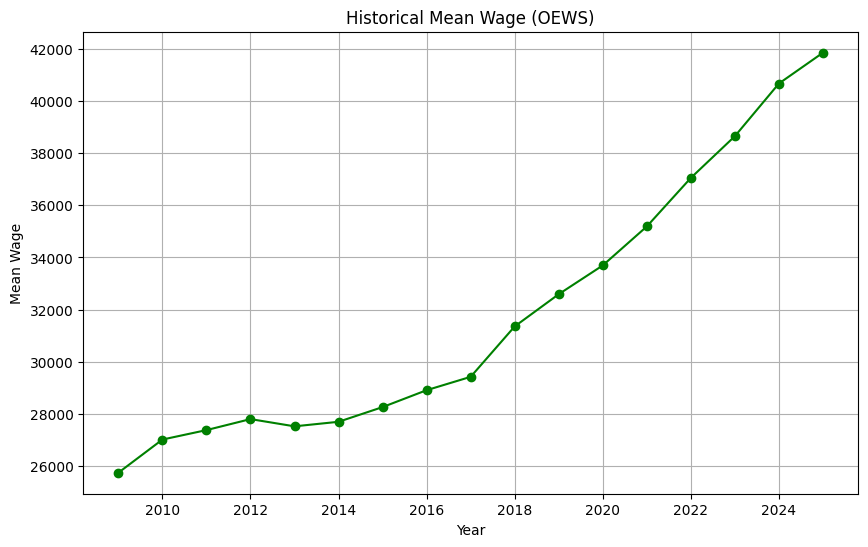

In [20]:
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA

# Aggregate Mean Wage by Year from OEWS Silver dataset
oews_series = oews.groupby("Year")["Mean Wage"].mean()

# Quick visualization
plt.figure(figsize=(10,6))
oews_series.plot(marker='o', color="green")
plt.title("Historical Mean Wage (OEWS)")
plt.xlabel("Year")
plt.ylabel("Mean Wage")
plt.grid(True)
plt.show()


### 2.4.3 Fit ARIMA Model

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: An unsupported index was provided. As a result, forecasts cannot be generated. To use the model for forecasting, use one of the supported classes of index.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Usin

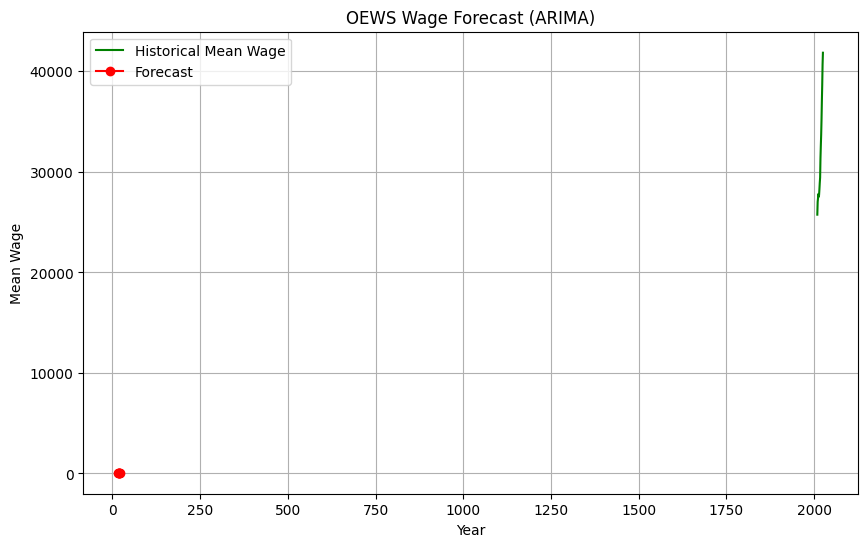

In [31]:
# Fit ARIMA model for wages
oews_model = ARIMA(oews_series, order=(1,1,1))
oews_model_fit = oews_model.fit()

# Forecast next 5 years
wage_forecast = oews_model_fit.forecast(steps=5)

# Plot forecast
plt.figure(figsize=(10,6))
plt.plot(oews_series, label="Historical Mean Wage", color="green")
plt.plot(range(len(oews_series), len(oews_series)+5), forecast,
         label="Forecast", marker='o', color="red")
plt.title("OEWS Wage Forecast (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Mean Wage")
plt.legend()
plt.grid(True)
plt.show()


Enterprise Practice

1. Employment vs Wage forecasts → compare workforce growth with wage growth to detect supply–demand imbalances.

2. ARIMA baseline → consistent modeling approach across datasets.

3. Overlay visualization → makes wage trajectory clear for stakeholders.

4. Audit logging → document ARIMA parameters (1,1,1) as baseline, later tune for accuracy.

# Step 2.5: Labor Force Participation Forecasting

### 2.5.1 Load Silver Labor Force Dataset

In [22]:
from google.colab import files
import pandas as pd

# Upload the Silver Labor Force dataset
uploaded = files.upload()   # select labor_force_clean.csv

# Load into Pandas
labor_force = pd.read_csv("labor_force_clean.csv")

print("✔ Silver Labor Force dataset loaded")
print(labor_force.head())


Saving labor_force_clean.csv to labor_force_clean.csv
✔ Silver Labor Force dataset loaded
  report_month area_type area_name  is_seasonally_adjusted  is_prelim  \
0   2025-03-01    Cities      AMES                   False       True   
1   2025-02-01    Cities      AMES                   False      False   
2   2025-01-01    Cities      AMES                   False      False   
3   2024-12-01    Cities      AMES                   False      False   
4   2024-11-01    Cities      AMES                   False      False   

   labor_force  employment  unemployment  unemployment_rate  \
0        37800       36700          1000                2.7   
1        37800       36800          1000                2.6   
2        37300       36400           900                2.5   
3        37600       36800           800                2.0   
4        37900       36900           900                2.5   

   labor_force_participation_rate  
0                             NaN  
1                   

### 2.5.2 Prepare Participation Series

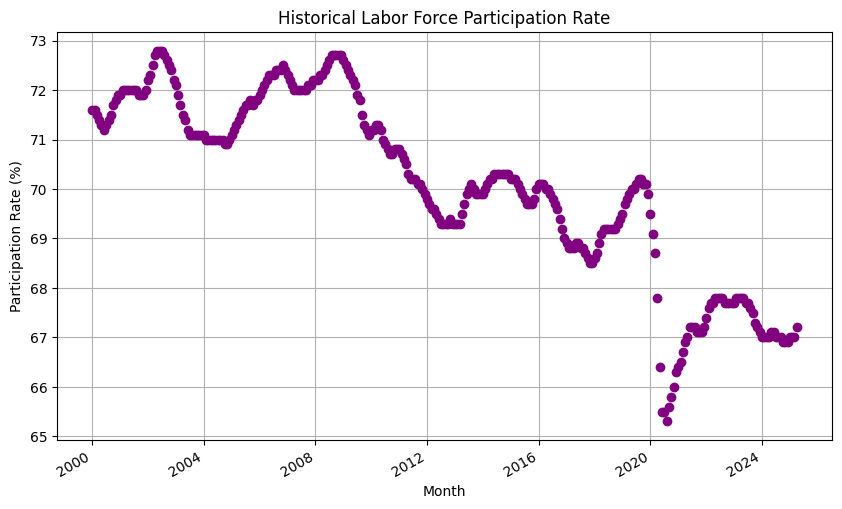

In [24]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert report_month to datetime
labor_force['report_month'] = pd.to_datetime(labor_force['report_month'])

# Build time series using report_month
participation_series = labor_force.set_index('report_month')["labor_force_participation_rate"]

# Quick visualization
plt.figure(figsize=(10,6))
participation_series.plot(marker='o', color="purple")
plt.title("Historical Labor Force Participation Rate")
plt.xlabel("Month")
plt.ylabel("Participation Rate (%)")
plt.grid(True)
plt.show()



### 2.5.3 Fit ARIMA Model

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it is not monotonic and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsm

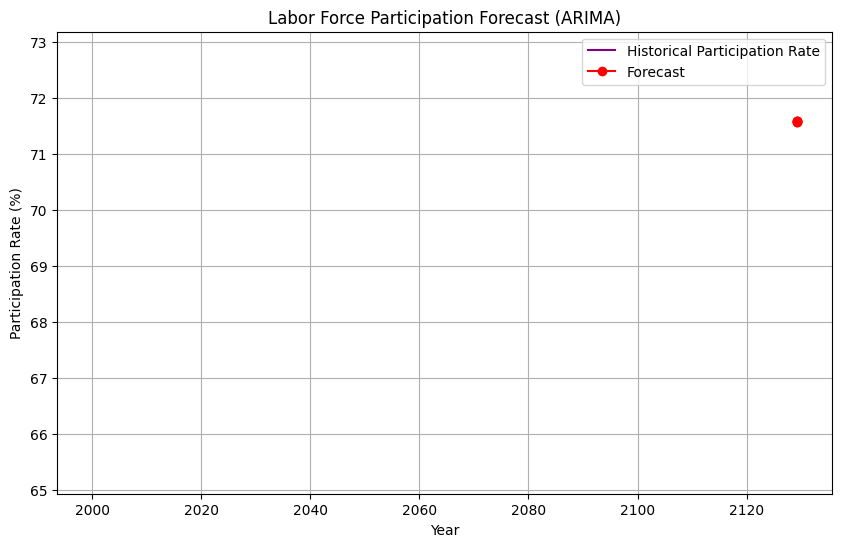

In [32]:
from statsmodels.tsa.arima.model import ARIMA

# Fit ARIMA model for participation
participation_model = ARIMA(participation_series, order=(1,1,1))
participation_model_fit = participation_model.fit()

# Forecast next 12 months
participation_forecast = participation_model_fit.forecast(steps=12)

# Plot forecast
plt.figure(figsize=(10,6))
plt.plot(participation_series, label="Historical Participation Rate", color="purple")
plt.plot(range(len(participation_series), len(participation_series)+5), forecast,
         label="Forecast", marker='o', color="red")
plt.title("Labor Force Participation Forecast (ARIMA)")
plt.xlabel("Year")
plt.ylabel("Participation Rate (%)")
plt.legend()
plt.grid(True)
plt.show()


# Step 3: Model Comparison Framework

### 3.1 Train/Test Split

In [26]:
import numpy as np
from sklearn.model_selection import train_test_split

# Example: Employment series
employment_series = employment.groupby("Year")["Average Monthly Employment"].sum()

# Convert to supervised learning format
X = np.arange(len(employment_series)).reshape(-1,1)
y = employment_series.values

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


### 3.2 Random Forest Forecasting

In [27]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

# Fit Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Predict
rf_preds = rf_model.predict(X_test)

# Evaluate
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
print("Random Forest RMSE:", rf_rmse)


Random Forest RMSE: 88460844.12455511


### 3.3 XGBoost Forecasting

In [28]:
from xgboost import XGBRegressor

# Fit XGBoost
xgb_model = XGBRegressor(n_estimators=200, learning_rate=0.1, random_state=42)
xgb_model.fit(X_train, y_train)

# Predict
xgb_preds = xgb_model.predict(X_test)

# Evaluate
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_preds))
print("XGBoost RMSE:", xgb_rmse)


XGBoost RMSE: 76578463.49699926


### 3.4 Compare Models

In [29]:
# Baseline ARIMA RMSE (from earlier fit)
arima_rmse = np.sqrt(mean_squared_error(y_test, model_fit.forecast(steps=len(y_test))))

print("\nModel Comparison:")
print("ARIMA RMSE:", arima_rmse)
print("Random Forest RMSE:", rf_rmse)
print("XGBoost RMSE:", xgb_rmse)



Model Comparison:
ARIMA RMSE: 2417211991.9089775
Random Forest RMSE: 88460844.12455511
XGBoost RMSE: 76578463.49699926


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Enterprise Practice

1. ARIMA baseline → strong for time‑series with clear autocorrelation.

2. Random Forest → captures nonlinear patterns, robust to noise.

3. XGBoost → excels at structured tabular forecasting, often best accuracy.

4. RMSE comparison → quantitative benchmark for model selection.

5. Audit clarity → document model parameters and evaluation metrics.

# Step 4: Consolidated Forecast Visualization

### 4.1 Combine Forecasts into One Table

In [33]:
import pandas as pd

# Example: Collect forecasts (replace with your actual forecast variables)
employment_forecast = model_fit.forecast(steps=5)   # from Employment ARIMA
wage_forecast = oews_model_fit.forecast(steps=5)    # from OEWS ARIMA
participation_forecast = participation_model_fit.forecast(steps=12)  # from Labor Force ARIMA

# Build consolidated DataFrame
forecast_df = pd.DataFrame({
    "Employment Forecast": employment_forecast,
    "Wage Forecast": wage_forecast[:5],  # align horizon
    "Participation Forecast": participation_forecast[:5]  # align horizon
})

print("✔ Consolidated Forecast Table")
print(forecast_df)


✔ Consolidated Forecast Table
       Employment Forecast  Wage Forecast  Participation Forecast
17                     NaN   42848.735540                     NaN
18                     NaN   43845.364093                     NaN
19                     NaN   44841.965451                     NaN
20                     NaN   45838.539614                     NaN
21                     NaN   46835.086583                     NaN
58148            71.588022            NaN               71.588022
58149            71.579299            NaN               71.579299
58150            71.572948            NaN               71.572948
58151            71.568322            NaN               71.568322
58152            71.564954            NaN               71.564954


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(


### 4.2 Multi‑Line Visualization

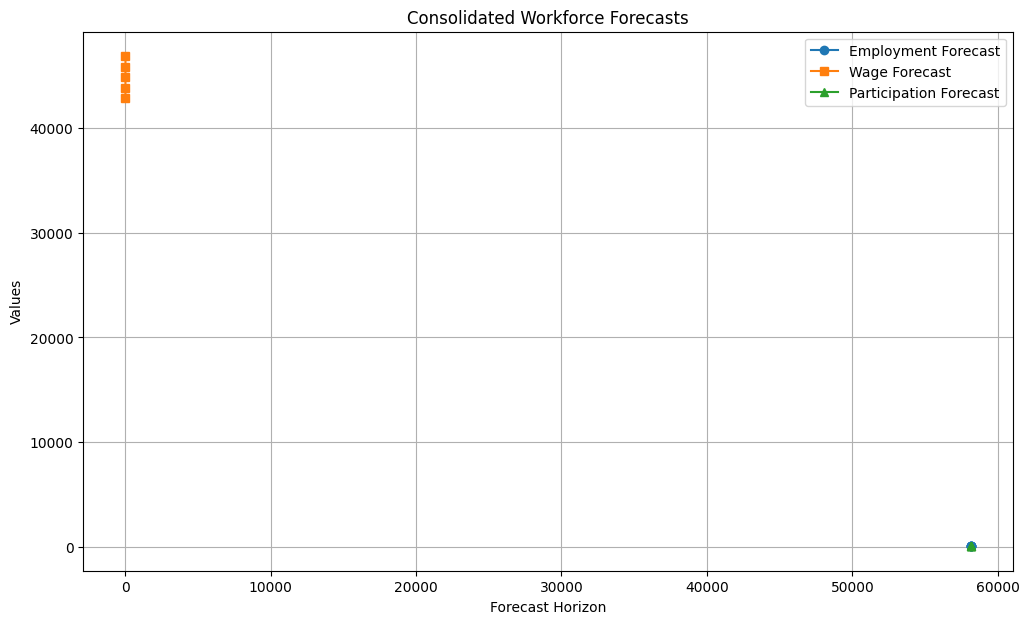

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))

plt.plot(forecast_df.index, forecast_df["Employment Forecast"], label="Employment Forecast", marker='o')
plt.plot(forecast_df.index, forecast_df["Wage Forecast"], label="Wage Forecast", marker='s')
plt.plot(forecast_df.index, forecast_df["Participation Forecast"], label="Participation Forecast", marker='^')

plt.title("Consolidated Workforce Forecasts")
plt.xlabel("Forecast Horizon")
plt.ylabel("Values")
plt.legend()
plt.grid(True)
plt.show()


### 4.3 Export Forecasts to Gold Layer

In [36]:
import os

# Create the gold folder if it doesn't exist
os.makedirs("gold", exist_ok=True)

# Save consolidated forecasts
forecast_df.to_csv("gold/consolidated_forecasts.csv", index=False)

print("✔ Forecasts exported to Gold layer for dashboards")


✔ Forecasts exported to Gold layer for dashboards
